#                          Uber NYC Trip Analysis

## Basic Exploration

In [62]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the April 2014 Uber dataset.

april=pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-apr14.csv')


In [3]:
april.shape

(564516, 4)

In [4]:
april.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564516 entries, 0 to 564515
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  564516 non-null  object 
 1   Lat        564516 non-null  float64
 2   Lon        564516 non-null  float64
 3   Base       564516 non-null  object 
dtypes: float64(2), object(2)
memory usage: 17.2+ MB


In [5]:
# Display first 10 rows.

april.head(10)

,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512
5,4/1/2014 0:33:00,40.7383,-74.0403,B02512
6,4/1/2014 0:39:00,40.7223,-73.9887,B02512
7,4/1/2014 0:45:00,40.7620,-73.9790,B02512
8,4/1/2014 0:55:00,40.7524,-73.9960,B02512
9,4/1/2014 1:01:00,40.7575,-73.9846,B02512


In [6]:
# What columns are present?

april.columns


Index(['Date/Time', 'Lat', 'Lon', 'Base'], dtype='object')

In [7]:
# Convert Date/Time column to datetime.
april['Date/Time']=pd.to_datetime(april['Date/Time'])

april['Date/Time'].dtype


dtype('<M8[ns]')

In [8]:
# Extract hour, day, weekday from Date/Time.
april['hour']=april['Date/Time'].dt.hour
april['day']=april['Date/Time'].dt.day
april['weekday']=april['Date/Time'].dt.day_name()

april.sample(5,random_state=10)

,Date/Time,Lat,Lon,Base,hour,day,weekday
507728,2014-04-25 17:21:00,40.7251,-74.0057,B02682,17,25,Friday
351979,2014-04-04 09:34:00,40.7141,-73.9902,B02682,9,4,Friday
144077,2014-04-21 19:09:00,40.7576,-73.9713,B02598,19,21,Monday
368783,2014-04-05 22:14:00,40.6871,-73.9364,B02682,22,5,Saturday
194056,2014-04-28 15:42:00,40.7412,-73.9983,B02598,15,28,Monday


In [9]:
# What’s the shape of the data?
april.shape


(564516, 7)

In [10]:
# Are there any missing values?
april.isnull().sum()

Date/Time    0
Lat          0
Lon          0
Base         0
hour         0
day          0
weekday      0
dtype: int64

## Concatenation

In [11]:
# Load May 2014 Uber dataset 

may=pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/uber-tlc-foil-response/master/uber-trip-data/uber-raw-data-may14.csv')


In [12]:
may.head(5)

,Date/Time,Lat,Lon,Base
0,5/1/2014 0:02:00,40.7521,-73.9914,B02512
1,5/1/2014 0:06:00,40.6965,-73.9715,B02512
2,5/1/2014 0:15:00,40.7464,-73.9838,B02512
3,5/1/2014 0:17:00,40.7463,-74.0011,B02512
4,5/1/2014 0:17:00,40.7594,-73.9734,B02512


In [13]:
may.shape

(652435, 4)

In [14]:
may['Date/Time']=pd.to_datetime(may['Date/Time'])
may['hour']=may['Date/Time'].dt.hour
may['day']=may['Date/Time'].dt.day
may['weekday']=may['Date/Time'].dt.day_name()

In [15]:
# Concatenate April and May datasets vertically.Reset index after concatenation.
# Add a column Month for each row.

april['month']=april['Date/Time'].dt.month_name()
may['month']=may['Date/Time'].dt.month_name()


april_may=pd.concat([april,may],ignore_index=True)
april_may.shape

(1216951, 8)

In [16]:
april_may[april_may['month']=='May']

,Date/Time,Lat,Lon,Base,hour,day,weekday,month
564516,2014-05-01 00:02:00,40.7521,-73.9914,B02512,0,1,Thursday,May
564517,2014-05-01 00:06:00,40.6965,-73.9715,B02512,0,1,Thursday,May
564518,2014-05-01 00:15:00,40.7464,-73.9838,B02512,0,1,Thursday,May
564519,2014-05-01 00:17:00,40.7463,-74.0011,B02512,0,1,Thursday,May
564520,2014-05-01 00:17:00,40.7594,-73.9734,B02512,0,1,Thursday,May
...,...,...,...,...,...,...,...,...
1216946,2014-05-31 23:45:00,40.7309,-74.0014,B02764,23,31,Saturday,May
1216947,2014-05-31 23:52:00,40.7528,-73.9798,B02764,23,31,Saturday,May
1216948,2014-05-31 23:55:00,40.7158,-73.9519,B02764,23,31,Saturday,May
1216949,2014-05-31 23:56:00,40.6961,-73.8997,B02764,23,31,Saturday,May


In [17]:
# Group by Month and count trips.

april_may.groupby('month').size()


month
April    564516
May      652435
dtype: int64

## Merging Datasets

In [18]:
april_may['Base'].unique()


array(['B02512', 'B02598', 'B02617', 'B02682', 'B02764'], dtype=object)

In [19]:
# Create a sample DataFrame with base zones and boroughs:

zone_data=pd.DataFrame({'Base': ['B02512', 'B02598', 'B02617'],
                        
                        'Borough': ['Manhattan', 'Queens', 'Brooklyn']
                        })

In [20]:
# Merge it with the April+May Uber data on Base.

april_may_merged=pd.merge(april_may,zone_data,on='Base',how='outer')
april_may_merged


,Date/Time,Lat,Lon,Base,hour,day,weekday,month,Borough
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday,April,Manhattan
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday,April,Manhattan
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday,April,Manhattan
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday,April,Manhattan
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday,April,Manhattan
...,...,...,...,...,...,...,...,...,...
1216946,2014-05-31 23:45:00,40.7309,-74.0014,B02764,23,31,Saturday,May,NaN
1216947,2014-05-31 23:52:00,40.7528,-73.9798,B02764,23,31,Saturday,May,NaN
1216948,2014-05-31 23:55:00,40.7158,-73.9519,B02764,23,31,Saturday,May,NaN
1216949,2014-05-31 23:56:00,40.6961,-73.8997,B02764,23,31,Saturday,May,NaN


In [21]:
# How many trips per borough?

april_may_merged.groupby('Borough').size()



Borough
Brooklyn     230735
Manhattan     72301
Queens       443812
dtype: int64

In [22]:
# another

april_may_merged['Borough'].value_counts()


Borough
Queens       443812
Brooklyn     230735
Manhattan     72301
Name: count, dtype: int64

In [23]:
# Merge only those bases that exist in both.

april_may_merged_with_common_base=pd.merge(april_may,zone_data,on='Base',how='inner')
april_may_merged_with_common_base

,Date/Time,Lat,Lon,Base,hour,day,weekday,month,Borough
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday,April,Manhattan
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday,April,Manhattan
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday,April,Manhattan
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday,April,Manhattan
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday,April,Manhattan
...,...,...,...,...,...,...,...,...,...
746843,2014-05-31 23:59:00,40.7270,-73.9912,B02617,23,31,Saturday,May,Brooklyn
746844,2014-05-31 23:59:00,41.0545,-74.0693,B02617,23,31,Saturday,May,Brooklyn
746845,2014-05-31 23:59:00,40.7033,-73.9262,B02617,23,31,Saturday,May,Brooklyn
746846,2014-05-31 23:59:00,40.7304,-74.0001,B02617,23,31,Saturday,May,Brooklyn


In [24]:
# Do a left merge, what happens with missing Boroughs?

left_join=pd.merge(april_may,zone_data,how='left')
left_join

,Date/Time,Lat,Lon,Base,hour,day,weekday,month,Borough
0,2014-04-01 00:11:00,40.7690,-73.9549,B02512,0,1,Tuesday,April,Manhattan
1,2014-04-01 00:17:00,40.7267,-74.0345,B02512,0,1,Tuesday,April,Manhattan
2,2014-04-01 00:21:00,40.7316,-73.9873,B02512,0,1,Tuesday,April,Manhattan
3,2014-04-01 00:28:00,40.7588,-73.9776,B02512,0,1,Tuesday,April,Manhattan
4,2014-04-01 00:33:00,40.7594,-73.9722,B02512,0,1,Tuesday,April,Manhattan
...,...,...,...,...,...,...,...,...,...
1216946,2014-05-31 23:45:00,40.7309,-74.0014,B02764,23,31,Saturday,May,NaN
1216947,2014-05-31 23:52:00,40.7528,-73.9798,B02764,23,31,Saturday,May,NaN
1216948,2014-05-31 23:55:00,40.7158,-73.9519,B02764,23,31,Saturday,May,NaN
1216949,2014-05-31 23:56:00,40.6961,-73.8997,B02764,23,31,Saturday,May,NaN


In [25]:
left_join['Borough'].isnull().sum()

470103

In [26]:
# Do an outer merge and count how many NaN in Borough.
april_may_merged=pd.merge(april_may,zone_data,on='Base',how='outer')
april_may_merged['Borough'].isna().sum()

470103

## Advanced Indexing

In [ ]:
# Set Date/Time as index.
april_may['Date/Time'] = pd.to_datetime(april_may['Date/Time'])
april_may.set_index('Date/Time', inplace=True)  
april_may = april_may.sort_index()


In [31]:
# Slice all trips between April 15 and April 20.

df_slice = april_may['2014-04-15':'2014-04-20']
df_slice


,Lat,Lon,Base,hour,day,weekday,month
Date/Time,,,,,,,
2014-04-15 00:00:00,40.7362,-73.9977,B02682,0,15,Tuesday,April
2014-04-15 00:00:00,40.6444,-73.7834,B02682,0,15,Tuesday,April
2014-04-15 00:01:00,40.7176,-73.9580,B02682,0,15,Tuesday,April
2014-04-15 00:01:00,40.7166,-74.0039,B02598,0,15,Tuesday,April
2014-04-15 00:01:00,40.7262,-73.9864,B02682,0,15,Tuesday,April
...,...,...,...,...,...,...,...
2014-04-20 23:59:00,40.7571,-73.9899,B02598,23,20,Sunday,April
2014-04-20 23:59:00,40.7318,-73.9854,B02617,23,20,Sunday,April
2014-04-20 23:59:00,40.6933,-73.9113,B02682,23,20,Sunday,April


In [34]:
# Resample by day and count trips.
daily_trips=april_may.resample('D').size()
daily_trips

Date/Time
2014-04-01    14546
2014-04-02    17474
2014-04-03    20701
2014-04-04    26714
2014-04-05    19521
              ...  
2014-05-27    17004
2014-05-28    22240
2014-05-29    24930
2014-05-30    24413
2014-05-31    21261
Freq: D, Length: 61, dtype: int64

In [40]:
#Resample by hour and get the average trips.
hourly_avg1 = april_may.resample('h').size().mean()
hourly_avg1


831.2506830601093

In [42]:
# What day had the most Uber trips?
daily_trips.idxmax(),daily_trips.max()

(Timestamp('2014-04-30 00:00:00'), 36251)

In [ ]:
# What time of day is busiest?

hourly = april_may.groupby(april_may.index.hour).size()
busiest_hour = hourly.idxmax(), hourly.max()
busiest_hour 

(17, 96983)

🔹 What is april_may.index.hour?


DataFrame april_may has a DatetimeIndex (i.e., Date/Time is the index).

(.index.hour extracts the hour part (0 to 23) from each datetime.)


📌 So you’re grouping data by hour of the day, not by date.

In [47]:
# Create a rolling average of trips per day (window=3)

rolling_avg = daily_trips.rolling(window=3).mean()
rolling_avg

Date/Time
2014-04-01             NaN
2014-04-02             NaN
2014-04-03    17573.666667
2014-04-04    21629.666667
2014-04-05    22312.000000
                  ...     
2014-05-27    12682.333333
2014-05-28    16482.000000
2014-05-29    21391.333333
2014-05-30    23861.000000
2014-05-31    23534.666667
Freq: D, Length: 61, dtype: float64

**A rolling average (also called moving average) is a technique used to smooth out short-term fluctuations and highlight longer-term trends in time series data.**

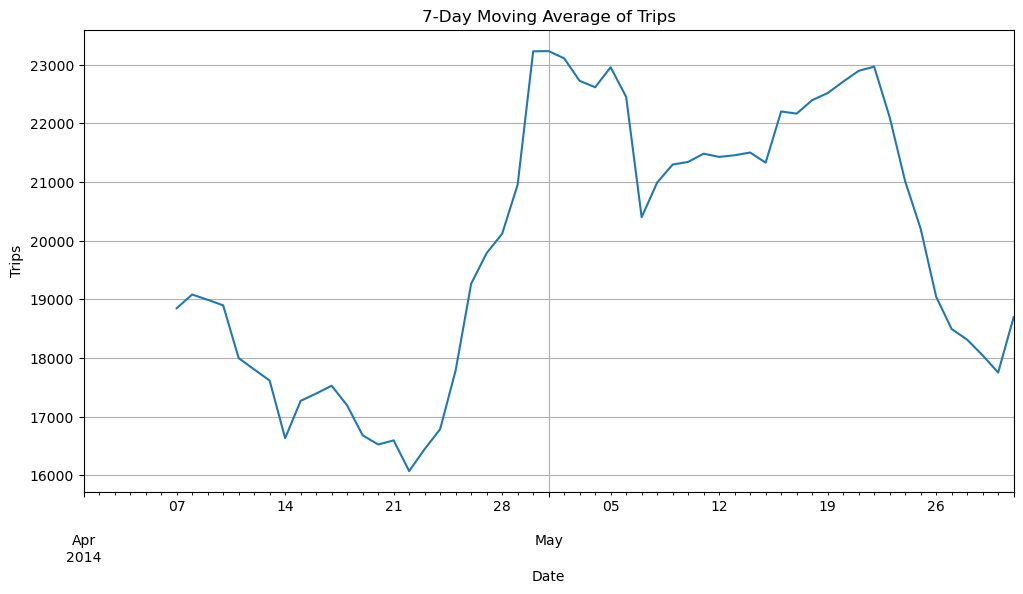

In [48]:
# Create a 7-day moving average plot.

daily_trips.rolling(7).mean().plot(title='7-Day Moving Average of Trips', figsize=(12,6))
plt.xlabel("Date")
plt.ylabel("Trips")
plt.grid()
plt.show()

##  Insight: 7-Day Moving Average of Trips

This graph shows the **7-day moving average** of Uber trips during **April to May 2014**.

###  What is a Moving Average?
A **7-day moving average** smooths out daily fluctuations by showing the average number of trips over the previous 7 days.  
This helps reveal **clear trends** in the data without getting distracted by daily noise.

---

###  Axis Details
- **X-axis (Date):** From April 1 to May 31, 2014
- **Y-axis (Trips):** Number of Uber trips per day (smoothed using a 7-day window)

---

###  Key Insights from the Chart

#### 🟦 Phase 1: Early April to April 22
- Trips are relatively **low and stable** (around 16,000 to 18,500)
- Possible reasons: regular weekday demand, fewer users, or seasonal patterns

#### 🟨 Phase 2: April 23 to May 2
- **Sharp spike** in average trips
- From ~17,000 to over 23,000 in a few days
- Likely due to **special events, increased demand, or promotions**

#### 🟩 Phase 3: May 3 to May 21
- Trips remain **consistently high** (above 22,000)
- This is the **peak period** for Uber during this time window

#### 🟥 Phase 4: After May 21
- **Decline** in average trips
- May indicate the end of a promotional period, demand drop, or return to normal levels

---

### ✅ Conclusion
The 7-day moving average highlights key patterns:
- A clear **growth spike** in late April,
- **Strong performance** in early to mid-May,
- Followed by a **decline** in the last week of May.

This technique is valuable for analyzing time series data with **reduced noise and better visibility** of trends.


## Geo-based Filtering

In [55]:
# How many trips had pickup latitude > 40.8?
(april_may['Lat']>40.8).sum()


26529

In [60]:
# Filter for pickups within Manhattan (lat 40.70-40.85 and lon -74 to -73.9).
manhattan_trips =april_may[(april_may['Lat'].between(40.70,40.85)) & (april_may['Lon'].between(-74, -73.9) )]

manhattan_trips

,Lat,Lon,Base,hour,day,weekday,month
Date/Time,,,,,,,
2014-04-01 00:00:00,40.7215,-73.9952,B02682,0,1,Tuesday,April
2014-04-01 00:00:00,40.7188,-73.9863,B02598,0,1,Tuesday,April
2014-04-01 00:00:00,40.7637,-73.9600,B02598,0,1,Tuesday,April
2014-04-01 00:01:00,40.7355,-73.9966,B02617,0,1,Tuesday,April
2014-04-01 00:02:00,40.7556,-73.9874,B02598,0,1,Tuesday,April
...,...,...,...,...,...,...,...
2014-05-31 23:59:00,40.7208,-73.9958,B02682,23,31,Saturday,May
2014-05-31 23:59:00,40.7225,-73.9918,B02682,23,31,Saturday,May
2014-05-31 23:59:00,40.7681,-73.9568,B02682,23,31,Saturday,May


In [64]:

# Create a new column Region: ‘Manhattan’, ‘Other’ based on coordinates.

april_may['Region'] = np.where(
    (april_may['Lat'].between(40.70, 40.85)) & (april_may['Lon'].between(-74, -73.9)),
    'Manhattan', 'Other')

april_may.sample(10)

,Lat,Lon,Base,hour,day,weekday,month,Region
Date/Time,,,,,,,,
2014-05-31 14:58:00,40.7147,-74.0162,B02682,14,31,Saturday,May,Other
2014-05-03 05:48:00,40.7474,-73.9723,B02682,5,3,Saturday,May,Manhattan
2014-04-25 08:36:00,40.7741,-73.8726,B02617,8,25,Friday,April,Other
2014-05-09 04:58:00,40.7037,-74.0107,B02598,4,9,Friday,May,Other
2014-05-10 23:43:00,40.7193,-73.9887,B02598,23,10,Saturday,May,Manhattan
2014-05-20 17:19:00,40.7264,-73.9993,B02617,17,20,Tuesday,May,Manhattan
2014-05-02 08:31:00,40.7607,-73.9947,B02598,8,2,Friday,May,Manhattan
2014-05-24 00:13:00,40.7392,-73.9878,B02617,0,24,Saturday,May,Manhattan
2014-05-31 14:40:00,40.7235,-74.0028,B02598,14,31,Saturday,May,Other


In [65]:
# Count trips by Region.

april_may['Region'].value_counts()

Region
Manhattan    808695
Other        408256
Name: count, dtype: int64

In [ ]:
🧮 Grouping & Aggregation
Group by Base and get trip counts.

Group by weekday and Base.

Group by Region and get average latitude.

Pivot table of trips by Base and weekday.

Unstack and restack a groupby object.

🔄 String Operations
Add a prefix to all column names: "Uber_".

Rename Uber_Base back to just Base.

Create column Hour_Label: ‘Morning’, ‘Evening’, etc. based on time.

Create Weekend column: True if trip was on Sat or Sun.

Create datetime column DayOfWeek_Hour (e.g., "Mon_14").

🧪 Analysis
What's the busiest day of the week?

What's the least busy hour on average?

Which Base is most active on weekends?

How many trips from each base each day?

Plot number of trips over time (line plot).

📦 Exporting and Importing
Export April trips to CSV.

Export May trips to Excel.

Save base zone summary to JSON.

Save entire combined DataFrame as pickle.

Load the pickle file and verify its contents.

